In [1]:
################################ Downloading Dataset #####################################
import os
import urllib.request
import tarfile
import pandas as pd
import re
from nltk.corpus import stopwords
import nltk
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download NLTK stopwords
nltk.download('stopwords')

# Define the URL and the output directory
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
output_dir = "/content/dataset"

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Define the file path for the downloaded file
file_path = os.path.join(output_dir, "aclImdb_v1.tar.gz")

# Download the dataset
print("Downloading dataset...")
urllib.request.urlretrieve(url, file_path)
print("Download complete!")

# Extract the dataset
print("Extracting dataset...")
with tarfile.open(file_path, "r:gz") as tar:
    tar.extractall(path=output_dir)
print("Extraction complete!")

# Path to extracted dataset
extracted_path = os.path.join(output_dir, "aclImdb")
print(f"Dataset is ready at: {extracted_path}")

################################ Load Data #####################################
def load_imdb_data(data_dir):
    data = {"review": [], "sentiment": []}
    for label in ["pos", "neg"]:
        folder = f"{data_dir}/{label}"
        for filename in os.listdir(folder):
            with open(os.path.join(folder, filename), encoding="utf-8") as f:
                data["review"].append(f.read())
                data["sentiment"].append(1 if label == "pos" else 0)
    return pd.DataFrame(data)

# Load training and test data
train_data = load_imdb_data(os.path.join(extracted_path, "train"))
test_data = load_imdb_data(os.path.join(extracted_path, "test"))

# Combine training and test data for preprocessing
all_data = pd.concat([train_data, test_data], ignore_index=True)

################################ Data Cleaning #####################################
# Define text cleaning function
def clean_text(text):
    text = re.sub(r"<.*?>", "", text)  # Remove HTML tags
    text = re.sub(r"[^a-zA-Z']", " ", text)  # Keep only alphabets and apostrophes
    text = text.lower()  # Convert to lowercase
    return text

# Clean the review column
all_data['cleaned_review'] = all_data['review'].apply(clean_text)

# Remove stopwords (optional)
stop_words = set(stopwords.words('english'))
all_data['cleaned_review'] = all_data['cleaned_review'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

################################ Tokenization and Padding #####################################
# Set parameters
vocab_size = 10000
max_sequence_length = 100

# Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(all_data['cleaned_review'])

# Tokenize and pad sequences
all_data['tokenized_review'] = tokenizer.texts_to_sequences(all_data['cleaned_review'])
padded_sequences = pad_sequences(all_data['tokenized_review'], maxlen=max_sequence_length, padding='post')

# Create labels
labels = all_data['sentiment'].values

################################ Train-Test Split #####################################
# Split into train, validation, and test sets
x_train, x_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

# Output shapes for confirmation
print("Training Data Shape:", x_train.shape)
print("Validation Data Shape:", x_val.shape)
print("Test Data Shape:", x_test.shape)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Download complete!
Extracting dataset...
Extraction complete!
Dataset is ready at: /content/dataset/aclImdb
Training Data Shape: (35000, 100)
Validation Data Shape: (7500, 100)
Test Data Shape: (7500, 100)


# **Applying RNN Model**

In [ ]:
################################### Step 2 Applying RNN Model ################################################

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping


# Model parameters
vocab_size = 10000  # Same as used during tokenization
embedding_dim = 64
rnn_units = 128
max_sequence_length = 100  # Same as used for padding

# Build the RNN model
rnn_model = Sequential()

# Add Embedding layer
rnn_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))

# Add SimpleRNN layer
rnn_model.add(SimpleRNN(rnn_units, return_sequences=False))

rnn_model.add(Dropout(0.5))

# Add Dense layer for binary classification
rnn_model.add(Dense(1, activation='sigmoid'))

# Compile the model
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Build the model explicitly (optional, but ensures dimensions are set)
rnn_model.build(input_shape=(None, max_sequence_length))

# Display model summary
rnn_model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 100, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_4 (SimpleRNN)             │ (None, 128)                 │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 664,833 (2.54 MB)

 Trainable params: 664,833 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
rnn_history = rnn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stopping]
)


Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 33s 57ms/step - accuracy: 0.5037 - loss: 0.7034 - val_accuracy: 0.5427 - val_loss: 0.6855
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 42s 58ms/step - accuracy: 0.5912 - loss: 0.6594 - val_accuracy: 0.7615 - val_loss: 0.5770
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6929 - loss: 0.5634 - val_accuracy: 0.7733 - val_loss: 0.5430
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7942 - loss: 0.4429 - val_accuracy: 0.7468 - val_loss: 0.6042
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.7953 - loss: 0.4297 - val_accuracy: 0.5540 - val_loss: 0.8243
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.7686 - loss: 0.4077 - val_accuracy: 0.5723 - val_loss: 0.8716


In [ ]:
# Evaluate on test data
rnn_loss, rnn_accuracy = rnn_model.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss: {rnn_loss:.4f}")
print(f"Test Accuracy: {rnn_accuracy:.4f}")


235/235 - 2s - 9ms/step - accuracy: 0.7747 - loss: 0.5456
Test Loss: 0.5456
Test Accuracy: 0.7747


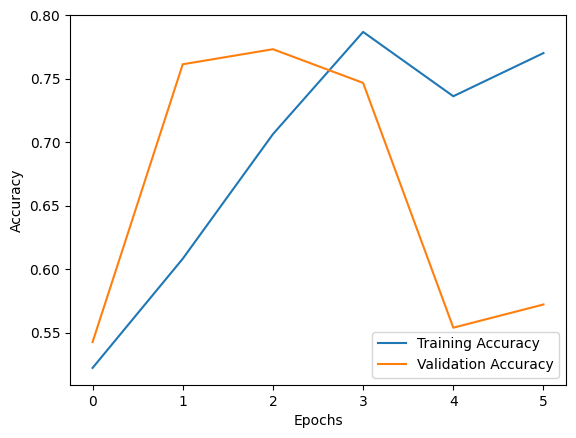

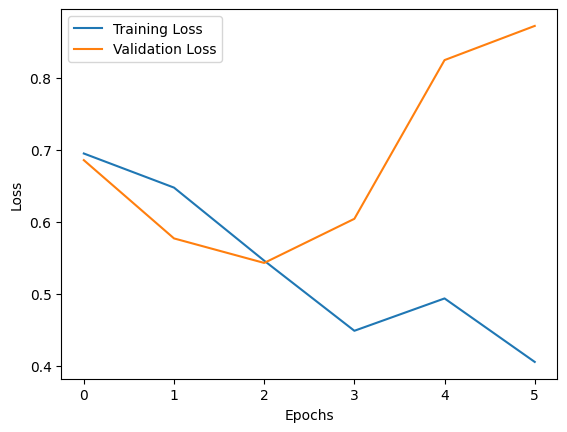

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(rnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(rnn_history.history['loss'], label='Training Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# **Applying LSTM Model**

In [ ]:
################################### Step 2 Applying LSTM Model ################################################

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# LSTM Model parameters
lstm_units = 128  # Number of units for the LSTM layer
embedding_dim = 64  # Embedding dimension, same as RNN model
vocab_size = 10000  # Same vocabulary size as RNN model
max_sequence_length = 100  # Same sequence length as RNN model

# Build the LSTM model
lstm_model = Sequential()

# Add Embedding layer
lstm_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))

# Add LSTM layer
lstm_model.add(LSTM(lstm_units, return_sequences=False))

# Add Dropout layer to avoid overfitting
lstm_model.add(Dropout(0.5))

# Add Dense layer for binary classification
lstm_model.add(Dense(1, activation='sigmoid'))

# Compile the model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Build the model explicitly (optional, but ensures dimensions are set)
lstm_model.build(input_shape=(None, max_sequence_length))

# Display model summary
lstm_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ (None, 100, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 738,945 (2.82 MB)

 Trainable params: 738,945 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the LSTM model
lstm_history = lstm_model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping]
)


Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 118s 211ms/step - accuracy: 0.5937 - loss: 0.6612 - val_accuracy: 0.5764 - val_loss: 0.6694
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 117s 213ms/step - accuracy: 0.7311 - loss: 0.5581 - val_accuracy: 0.7905 - val_loss: 0.5269
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 139s 207ms/step - accuracy: 0.7533 - loss: 0.5032 - val_accuracy: 0.8744 - val_loss: 0.3104
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 141s 206ms/step - accuracy: 0.8961 - loss: 0.2659 - val_accuracy: 0.8703 - val_loss: 0.3165
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 113s 206ms/step - accuracy: 0.9214 - loss: 0.2133 - val_accuracy: 0.8735 - val_loss: 0.3199
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 141s 204ms/step - accuracy: 0.9417 - loss: 0.1743 - val_accuracy: 0.8688 - val_loss: 0.3752


In [ ]:
# Evaluate LSTM Model

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(x_test, y_test)
print(f"LSTM Model - Test Accuracy:")
print(f"Test Loss: {lstm_test_loss:.4f}")
print(f"Test Accuracy: {lstm_test_accuracy:.4f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8690 - loss: 0.3146
LSTM Model - Test Accuracy:
Test Loss: 0.3159
Test Accuracy: 0.8683


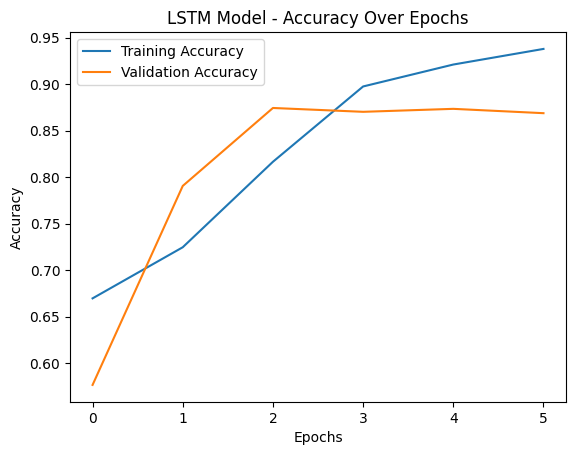

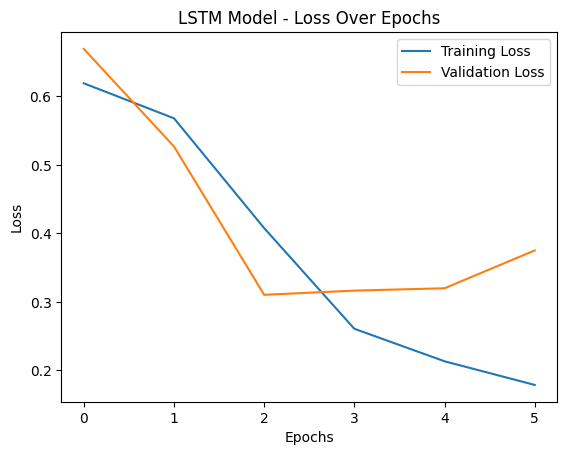

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy for LSTM
plt.plot(lstm_history.history['accuracy'], label='Training Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('LSTM Model - Accuracy Over Epochs')
plt.legend()
plt.show()

# Plot training and validation loss for LSTM
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM Model - Loss Over Epochs')
plt.legend()
plt.show()


In [ ]:
# Evaluate RNN Model
rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(x_test, y_test)
print(f"RNN Model - Test Accuracy: {rnn_test_accuracy:.4f}, Test Loss: {rnn_test_loss:.4f}")

# Evaluate LSTM Model
lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(x_test, y_test)
print(f"LSTM Model - Test Accuracy: {lstm_test_accuracy:.4f}, Test Loss: {lstm_test_loss:.4f}")


235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7721 - loss: 0.5490
RNN Model - Test Accuracy: 0.7747, Test Loss: 0.5456
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.8690 - loss: 0.3146
LSTM Model - Test Accuracy: 0.8683, Test Loss: 0.3159


# **Compare performance of RNN and LSTM model**

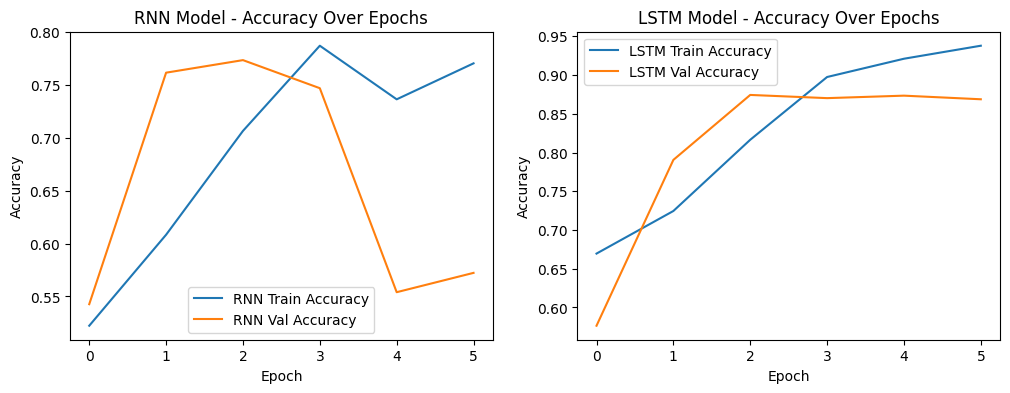

In [ ]:
import matplotlib.pyplot as plt

# Plot training history for RNN
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['accuracy'], label='RNN Train Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='RNN Val Accuracy')
plt.title('RNN Model - Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training history for LSTM
plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val Accuracy')
plt.title('LSTM Model - Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **Applying Transformer Model**

In [5]:
pip install transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [6]:
# Necessary Libraries

from transformers import BertTokenizer, TFBertForSequenceClassification, AdamWeightDecay
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [10]:
################################### Step 2 Applying Transformer Model ################################################
# Import necessary libraries
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification
from sklearn.model_selection import train_test_split
from transformers import AdamWeightDecay

# Load the pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenization function
def encode_texts(texts):
    return tokenizer(texts, padding=True, truncation=True, max_length=100, return_tensors='tf')

# Preprocess the IMDB dataset (use your preprocessed text data or Hugging Face dataset)
train_texts = all_data['cleaned_review'].values.tolist()  # Make sure you have 'cleaned_review' column
train_labels = all_data['sentiment'].values.tolist()

# Split the dataset into training and validation
x_train, x_val, y_train, y_val = train_test_split(train_texts, train_labels, test_size=0.2, random_state=42)

# Tokenize the data
train_encodings = encode_texts(x_train)
val_encodings = encode_texts(x_val)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((dict(val_encodings), y_val))

# Batch the datasets
train_dataset = train_dataset.batch(16)
val_dataset = val_dataset.batch(16)

# Load the pre-trained BERT model
model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Freeze only the first few layers (fine-tune the last few layers)
for layer in model.layers[:-4]:  # Fine-tune the last 4 layers
    layer.trainable = False

# Compile the model
optimizer = AdamWeightDecay(learning_rate=1e-5, weight_decay_rate=0.01)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
2500/2500 [==============================] - 975s 382ms/step - loss: 0.5811 - accuracy: 0.6897 - val_loss: 0.5847 - val_accuracy: 0.5682
Epoch 2/3
2500/2500 [==============================] - 934s 374ms/step - loss: 0.5416 - accuracy: 0.7158 - val_loss: 0.4159 - val_accuracy: 0.8163
Epoch 3/3
2500/2500 [==============================] - 939s 376ms/step - loss: 0.4134 - accuracy: 0.8583 - val_loss: 0.3932 - val_accuracy: 0.8648


In [11]:
# Evaluate the model
test_texts = all_data['cleaned_review'].values.tolist()
test_labels = all_data['sentiment'].values.tolist()

# Tokenize the test data
test_encodings = encode_texts(test_texts)

# Convert to TensorFlow dataset
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), test_labels))
test_dataset = test_dataset.batch(16)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")


3125/3125 [==============================] - 368s 118ms/step - loss: 0.3165 - accuracy: 0.8895
Test Accuracy: 0.8895, Test Loss: 0.3165


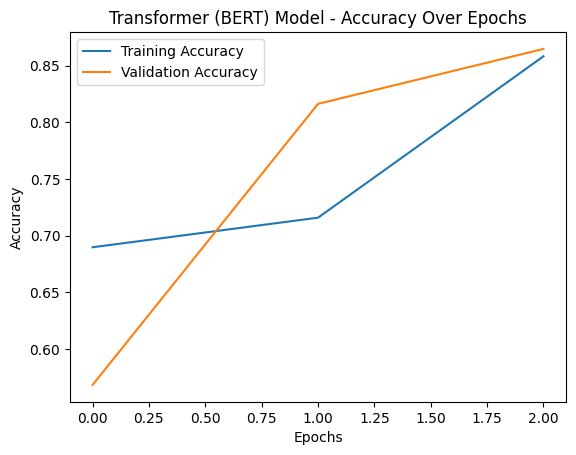

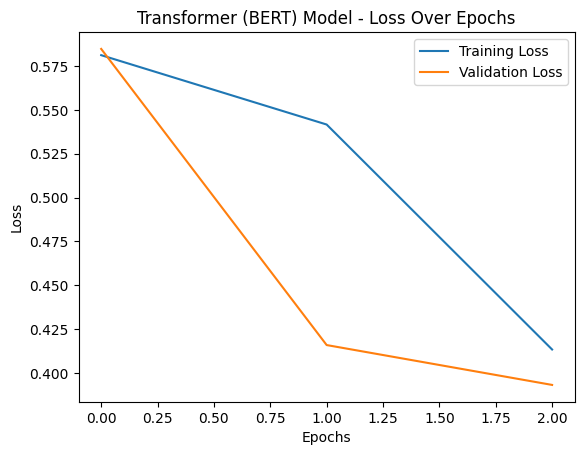

In [12]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Transformer (BERT) Model - Accuracy Over Epochs')
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Transformer (BERT) Model - Loss Over Epochs')
plt.show()
